Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import os 

Creating Directories

In [4]:
# Checking the current working directory to ensure we are in the correct path
print("Current working directory:", os.getcwd())

Current working directory: /content


In [5]:
# List all files in the current directory to verify the presence of the dataset
print("Files in the current directory:", os.listdir())

Files in the current directory: ['.config', 'requirements.txt', 'drive', 'sample_data']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# List all files in the data directory to verify the presence of the dataset
path = "/content/drive/MyDrive/predictive-maintenance-smart-factory/data/"

list_of_files = os.listdir(path)
print("Files in the data directory:", list_of_files)

Files in the data directory: ['ai4i2020.csv', 'predictive_maintenance.csv']


EDA of ai4i2020 Dataset

In [8]:
# Loading the dataset
df = pd.read_csv(os.path.join(path, "ai4i2020.csv"))
print("Dataset loaded successfully. Here are the first few rows:\n")
print(df.head())

Dataset loaded successfully. Here are the first few rows:

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF

In [9]:
print("Dataset information:")
print(df.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


In [11]:
# Quick EDA to check for missing values and basic statistics
print("\nMissing values in each column:")   
print(df.isnull().sum())


Missing values in each column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [12]:
# Qucik check for tthe failure types
print("\nFailure counts:")
print(df[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum())


Failure counts:
Machine failure    339
TWF                 46
HDF                115
PWF                 95
OSF                 98
RNF                 19
dtype: int64


EDA for predictive-maintenance Dataset

In [13]:
df_1 = pd.read_csv(os.path.join(path, "predictive_maintenance.csv"))

print("Dataset loaded successfully. Here are the first few rows:\n")
print(df_1.head())  



print("\n\nDataset Shape:", df_1.shape)




Dataset loaded successfully. Here are the first few rows:

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


Dataset Shape: (10000, 10)


In [14]:
print("Dataset information:")
print(df_1.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None


Merging the two datasets

In [15]:
#Merge on the two unique identifiers
df_merged = pd.merge(
    df, 
    df_1[['UDI', 'Product ID', 'Failure Type']],   # only take the useful different column
    on=['UDI', 'Product ID'],
    how='left'
)

print("Merged shape:", df_merged.shape)
print("\nNew columns added:", [col for col in df_merged.columns if col not in df.columns])

#

Merged shape: (10000, 15)

New columns added: ['Failure Type']


In [20]:
 #Save the merged dataset for future use
df_merged.to_csv(os.path.join(path, "merged_predictive_maintenance.csv"), index=False)
print("Merged dataset saved to data/ folder!")

Merged dataset saved to data/ folder!


EDA for Merged Dataset

In [21]:
# Basic information
print("=== Basic Info ===")
print(df_merged.info())
print("\n=== First 5 rows ===")
print(df_merged.head())
print("\nMissing values:\n", df_merged.isnull().sum().sum())  # should be 0

# Descriptive statistics for numeric sensors
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
print("\n=== Sensor Statistics ===")
print(df_merged[numeric_cols].describe())

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
 14  Fail

No missing data

Performing visual analysis


=== Failure Counts ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Type distribution (from second dataset):
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


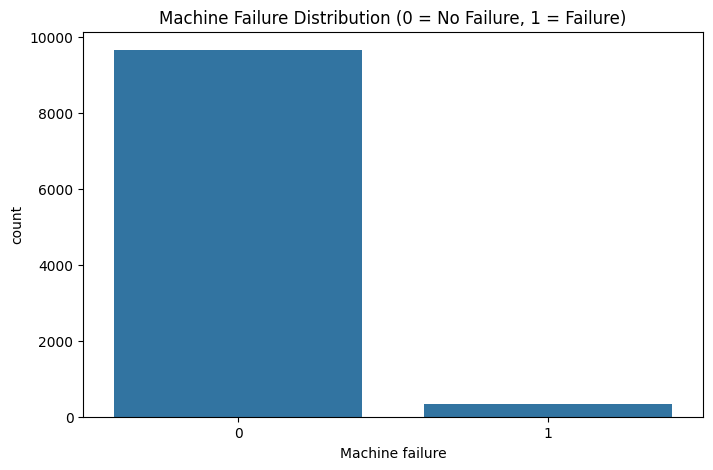

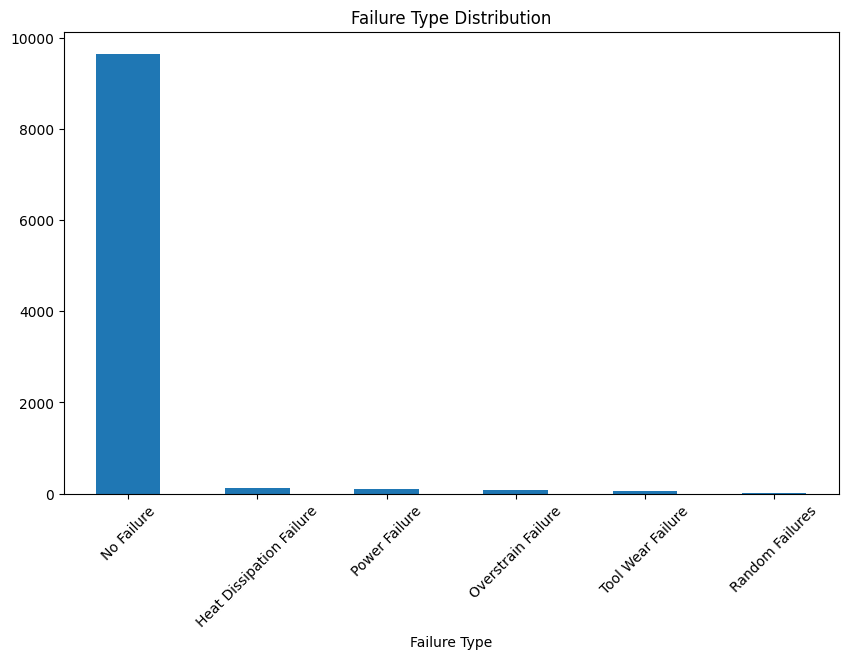

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Failure distribution
print("\n=== Failure Counts ===")
print(df_merged['Machine failure'].value_counts())
print("\nFailure Type distribution (from second dataset):")
print(df_merged['Failure Type'].value_counts())

# Plot failure distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df_merged, x='Machine failure')
plt.title('Machine Failure Distribution (0 = No Failure, 1 = Failure)')
plt.show()

# Failure Type breakdown
plt.figure(figsize=(10,6))
df_merged['Failure Type'].value_counts().plot(kind='bar')
plt.title('Failure Type Distribution')
plt.xticks(rotation=45)
plt.show()

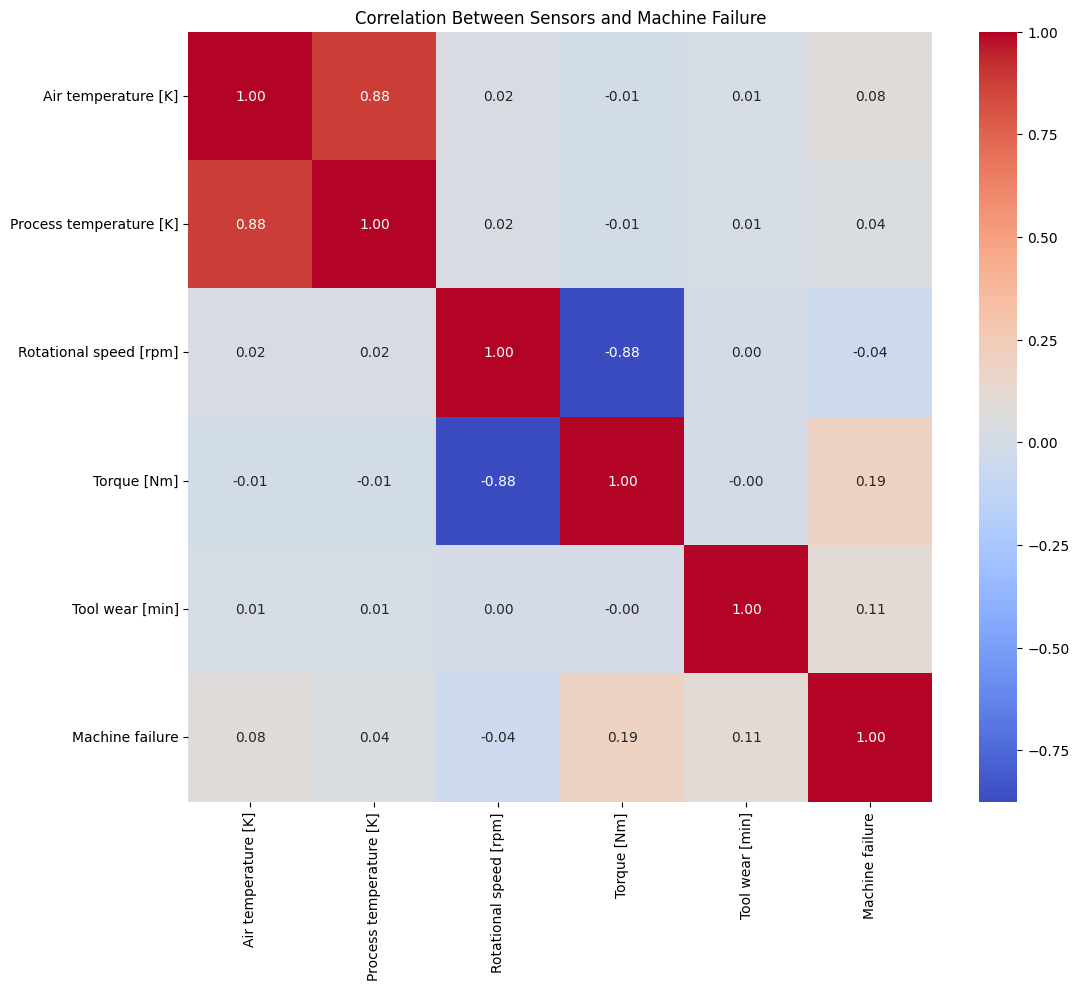

In [ ]:
# Correlation heatmap for understanding relationships
plt.figure(figsize=(12,10))
corr = df_merged[numeric_cols + ['Machine failure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Sensors and Machine Failure')
plt.show()

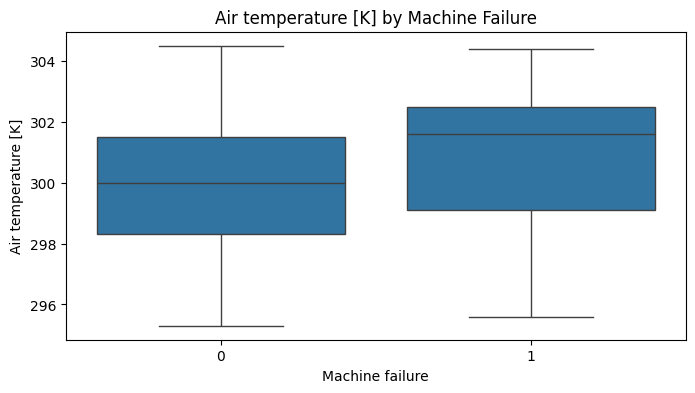

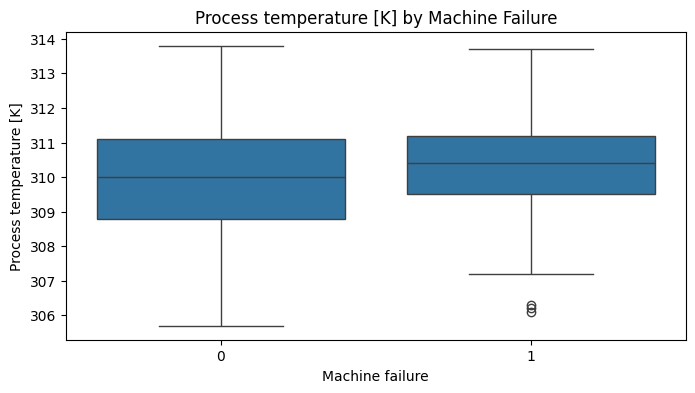

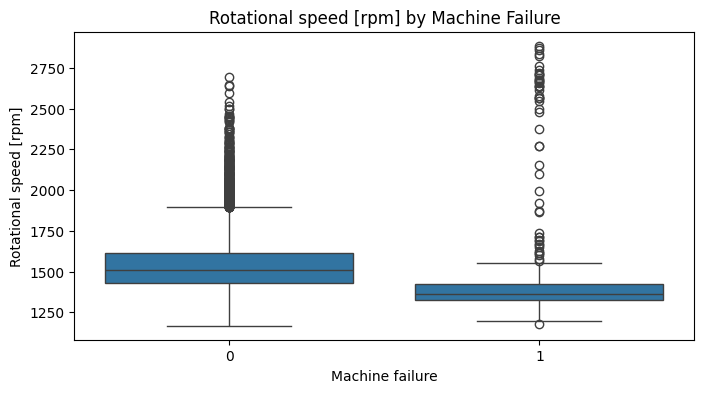

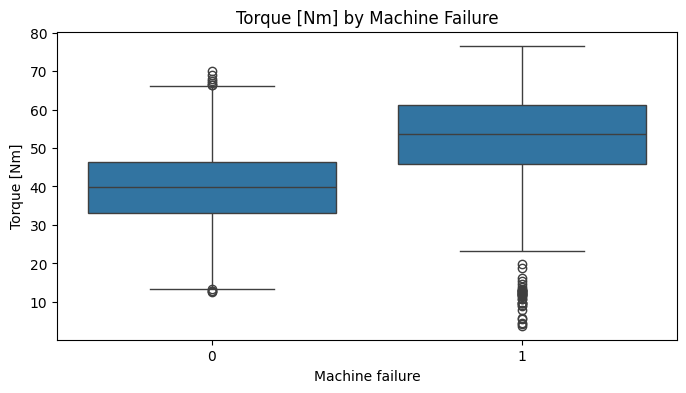

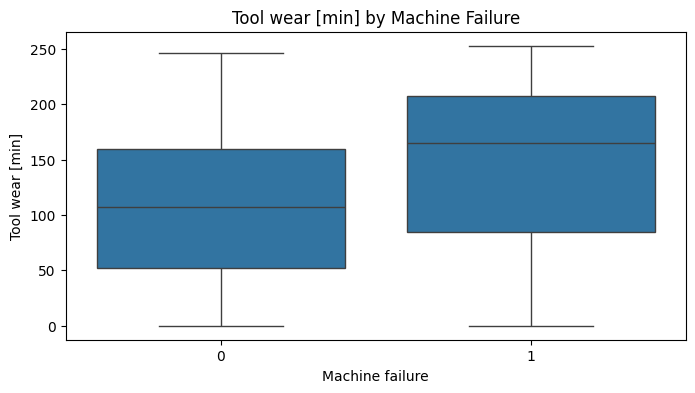

In [24]:
# Sensor distributions by failure
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_merged, x='Machine failure', y=col)
    plt.title(f'{col} by Machine Failure')
    plt.show()

## Boxplot Analysis

- Tool wear and Torque show visible shifts toward higher values in failure cases (Machine failure = 1).
- Rotational speed tends to be slightly lower during failures with some high outliers.
- Process temperature shows only minor differences.
- These patterns suggest that failures are driven more by mechanical stress (tool wear + torque) than by temperature alone.

## Key EDA Insights
- Failures are rare (~3.5% of samples) → we will need class balancing later.
- Tool wear and Torque show clearest shift in failure cases (see boxplots).
- Air & Process temperature are highly correlated (expected).
- Torque and Rotational speed have strong negative correlation due to constant power relationship in CNC motors.
- Low individual correlations with target confirm we need advanced ML + feature engineering.

## EDA Insights – Sensor Behavior During Failures

- **Torque** shows the clearest difference: Failures occur at significantly higher torque levels. This is a strong predictive signal.
- **Rotational speed** tends to be lower during failures, but extreme high speeds also appear risky.
- **Process temperature** shows only a small shift toward higher values in failure cases.
- Many outliers are visible, especially in rotational speed and torque. In predictive maintenance, these outliers often represent early warning signs rather than noise.
- The patterns confirm that failures are driven by **combinations** of sensor readings rather than single variables (explains the low individual correlations with the target).